In [128]:
import numpy as np
import matplotlib.pyplot as plt
import json
from skimage import io
import scipy.ndimage as ndi

In [129]:
def load_image(image_path):
    """
    Loads an image from a given file path.

    Args:
        image_path (str): The complete path to the image file.

    Returns:
        numpy.ndarray: The loaded image as an array of pixels.
    """
    image = io.imread(image_path)
    return image

In [130]:
def load_json(file_path):
    """
    Loads a JSON file and returns its content.

    Args:
        file_path (str): The path to the JSON file.

    Returns:
        list/dict: The parsed JSON data.
    """
    with open(file_path, "r", encoding="utf-8") as file:
        data = json.load(file)
    
    return data

In [131]:
def get_defect_coordinates_direct(json_data):
    """
    Parses JSON data to extract defect coordinates for a single image JSON file.

    Args:
        json_data (list): The list of dictionaries loaded from the JSON file.

    Returns:
        dict: A dictionary where keys are x-coordinates (columns) and values 
              are dictionaries containing lists of 'start' and 'stop' y-coordinates.
    """
    defect_dict = {}
    
    for item in json_data:
        for x_coord in item.get('x_coord', []):
            defect_dict[x_coord] = {
                'start': item.get('y_start', []), 
                'stop': item.get('y_stop', [])
            }
    return defect_dict

In [132]:
def normalize_to_8bit(image_array):
    """
    Normalizes an image array (e.g., 16-bit) to an 8-bit range (0 to 255).

    Args:
        image_array (numpy.ndarray): The input image array.

    Returns:
        numpy.ndarray: The normalized image array with dtype uint8.
    """
    img_np = np.array(image_array, dtype=np.float32)
    
    val_min = np.min(img_np)
    val_max = np.max(img_np)
    
    if val_max == val_min:
        return np.zeros_like(img_np, dtype=np.uint8)
        
    normalized_image = ((img_np - val_min) / (val_max - val_min)) * 255
    
    return normalized_image.astype(np.uint8)

In [133]:
def create_defect_mask_2d(shape, defect_dict):
    """
    Creates a 2D boolean mask pinpointing the exact locations of the defects 
    based on the provided defect dictionary coordinates.

    Args:
        shape (tuple): The (nrow, ncol) shape of the target image matrix.
        defect_dict (dict): A dictionary where keys are x-coordinates (columns) and values 
                            are dictionaries containing lists of 'start' and 'stop' y-coordinates.
            
    Returns:
        ndarray: A 2D boolean array where True indicates a defective pixel.
    """
    nrow, ncol = shape
    mask_2d = np.zeros(shape, dtype=bool)
    
    if not defect_dict:
        return mask_2d

    for col, intervals in defect_dict.items():
        if not (0 <= col < ncol):
            continue
        
        starts = intervals.get('start', [])
        stops = intervals.get('stop', [])
        
        # Run through each pair of Y intervals for this X column
        for y_start, y_stop in zip(starts, stops):
            y_start_clamped = max(0, int(y_start))
            y_stop_clamped = min(nrow, int(y_stop))
            
            mask_2d[y_start_clamped:y_stop_clamped, col] = True
            
    return mask_2d

In [134]:
def correct_stripes_with_frequency_interpolation(original_image, defect_dict):
    """
    Filters and corrects only the defect segments on the specified columns 
    using a hybrid Algotom approach that isolates low/high frequencies, 
    interpolates the stripe low frequencies horizontally, 
    and fuses the intact high frequency details back.
    
    All non defective pixels are kept 100% unchanged to preserve the original 
    image quality outside the faulty regions.

    Args:
        original_image : array_like 
            2D image array.
        defect_dict : dict
            A dictionary where keys are x-coordinates (columns) and values 
            are dictionaries containing lists of 'start' and 'stop' y-coordinates.
            
    Returns:
        array_like: The corrected 16-bit unsigned integer image matrix.
    """
    final_output = np.copy(original_image)
    nrow, ncol = final_output.shape
    
    # Generate exact 2D mask using the separated utility function
    exact_mask_2d = create_defect_mask_2d(final_output.shape, defect_dict)
                    
    if not np.any(exact_mask_2d):
        return original_image.astype(np.uint16)

    mat_float = original_image.astype(np.float32)

    # Layer 1: Vertical Frequency Separation
    # Apply a vertical Gaussian filter with sigma=11.0 to isolate the smooth 
    # background component containing the stripes.
    mat_low_freq = ndi.gaussian_filter1d(mat_float, sigma=11.0, axis=0)
    mat_high_freq = mat_float - mat_low_freq  # Retain 100% of clean high frequency details

    # Layer 2: Horizontal Linear Interpolation on Low Frequency
    mat_low_corrected = np.copy(mat_low_freq)
    
    # Iterate through each row to perform 1D horizontal interpolation across defects
    for r in range(nrow):
        error_mask_row = exact_mask_2d[r, :]
        if not np.any(error_mask_row):
            continue
            
        clean_indices = np.where(~error_mask_row)[0]
        error_indices = np.where(error_mask_row)[0]
        
        if len(clean_indices) > 1:
            # Perform Algotom 1D linear interpolation across faulty stripe points
            # using clean pixels from the left and right boundaries of the same row.
            interp_values = np.interp(error_indices, clean_indices, mat_low_freq[r, clean_indices])
            mat_low_corrected[r, error_indices] = interp_values

    # Layer 3: Fusion and Final Masked Compositing
    mat_final_corrected = mat_low_corrected + mat_high_freq
    
    # Clip and cast to preserve 16-bit dynamic range
    mat_corrected_16bit = np.clip(np.round(mat_final_corrected), 0, 65535).astype(np.uint16)
    
    # Replace only the defective regions; clean areas remain completely untouched
    final_output[exact_mask_2d] = mat_corrected_16bit[exact_mask_2d]
    
    return final_output.astype(np.uint16)

In [135]:
def display_comparison(original_image, processed_image):
    """
    Normalizes 16-bit images to 8-bit and plots them side-by-side for comparison.
    Uses the pre-existing normalize_to_8bit function.

    Args:
        original_image (numpy.ndarray): The raw original 16-bit image array.
        processed_image (numpy.ndarray): The destriped 16-bit image array.
    """
    # Scale both images to 8-bit strictly for rendering pipeline
    original_image_8bits = normalize_to_8bit(original_image)
    processed_image_8bits = normalize_to_8bit(processed_image)

    fig, axes = plt.subplots(1, 2, figsize=(14, 7))

    # Plot 1: The original corrupted image
    axes[0].imshow(original_image_8bits, cmap='gray')
    axes[0].set_title("Original Image", fontsize=12, fontweight='bold')
    axes[0].axis('off')

    # Plot 2: The destriped image processed by Algotom
    axes[1].imshow(processed_image_8bits, cmap='gray')
    axes[1].set_title("Corrected image", fontsize=12, fontweight='bold')
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

In [136]:
def pipeline_process_image_pure(image_path, json_path, show_result=True):
    """
    Processes an image using frequency separated interpolation algorithm
    Directly maps defect locations from a JSON configuration.

    Args:
        image_path (str): Path to read the target input image.
        json_path (str): Path to read the single image configuration JSON file.
        show_result (bool): If True, plots the side-by-side comparison on screen.

    Returns:
        corrected_image_16bit (numpy.ndarray): The resulting destriped 16-bit image array matrix.
    """
    # Load the original image 
    original_image = load_image(image_path)
    
    # Load the JSON data
    json_data = load_json(json_path)
        
    # Extract defect coordinates 
    defect_coords = get_defect_coordinates_direct(json_data)
    
    # Compute the correction matrix using the advanced Hybrid Frequency Split method
    corrected_image_16bit = correct_stripes_with_frequency_interpolation(original_image, defect_coords)
    
    # Display
    if show_result:
        display_comparison(original_image, corrected_image_16bit)
        
    return corrected_image_16bit

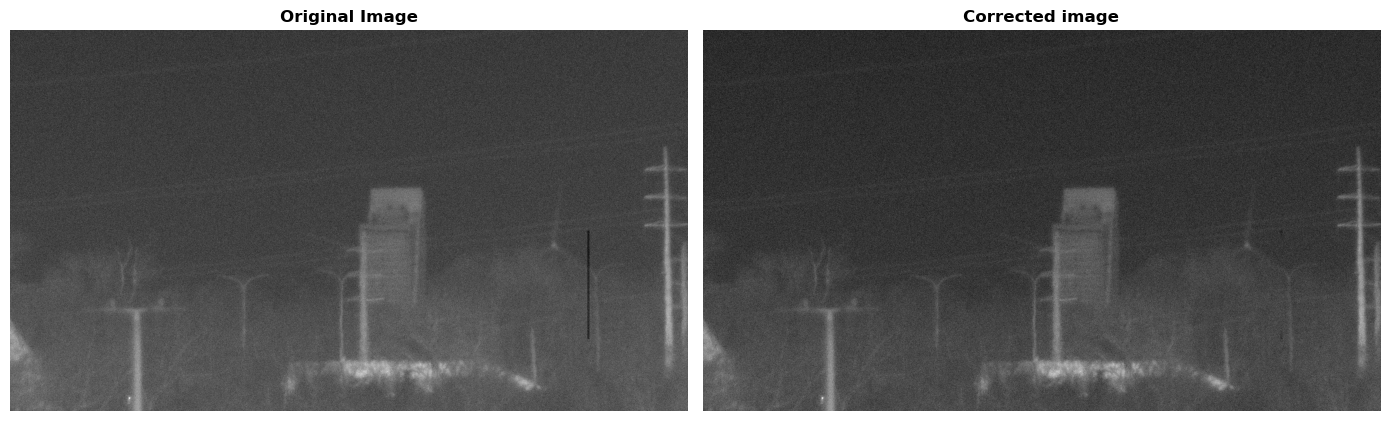

In [137]:
image_path = "/Users/thanhhiennguyenle/Documents/Data Challenge - Defective columns 2026/train/HD/sequence_1/low dyn with columns 2/frame_0043.png"
json_path  = "/Users/thanhhiennguyenle/Documents/Data Challenge - Defective columns 2026/train/HD/sequence_1/low dyn with columns 2/HD_sequence_1_config_2.json"

img_clean_16bit = pipeline_process_image_pure(image_path, json_path, show_result=True)